In [1]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch import device
import awkward as ak
import os
import torch.optim as optim
from matplotlib import pyplot as plt
import numpy as np

LEARNING_RATE = 5e-5
EPOCHS = 100
BATCH_SIZE = 128
DATA_PATH = r"C:\Users\J Birbou\ML_Class\HW8\data_pq"



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = ak.from_parquet(os.path.join(DATA_PATH, "train.pq"))

val_dataset = ak.from_parquet(os.path.join(DATA_PATH, "val.pq"))

test_dataset = ak.from_parquet(os.path.join(DATA_PATH, "test.pq")) 

def normalize_features(dataset, means=None, stds=None):
   
    times = dataset["data"][:, 0:1, :]
    x = dataset["data"][:, 1:2, :]
    y = dataset["data"][:, 2:3, :]
    
    if means is None or stds is None:
        means = {
            'time': ak.mean(times), 'x': ak.mean(x), 'y': ak.mean(y),
            'xpos': ak.mean(dataset['xpos']), 'ypos': ak.mean(dataset['ypos'])
        }
        stds = {
            'time': ak.std(times), 'x': ak.std(x), 'y': ak.std(y),
            'xpos': ak.std(dataset['xpos']), 'ypos': ak.std(dataset['ypos'])
        }

    norm_times = (times - means['time']) / stds['time']
    norm_x = (x - means['x']) / stds['x']
    norm_y = (y - means['y']) / stds['y']
    
    dataset["data"] = ak.concatenate([norm_times, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - means['xpos']) / stds['xpos']
    dataset["ypos"] = (dataset["ypos"] - means['ypos']) / stds['ypos']
    
    return dataset, means, stds


train_dataset, norm_means, norm_stds = normalize_features(train_dataset)

val_dataset, _, _ = normalize_features(val_dataset, norm_means, norm_stds)
test_dataset, _, _ = normalize_features(test_dataset, norm_means, norm_stds)

In [3]:

def collate_fn_transformer(batch):
   
    data_list = []
    labels = []
    lengths=[]

    for b in batch:
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
       
        tensordata = tensordata.to(dtype=torch.float32)

        lengths.append(tensordata.shape[0])

        data_list.append(tensordata)

        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) 

    data_vec=torch.cat(data_list) 

    return [data_vec, lengths], labels



In [4]:
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn_transformer
)
validation_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn_transformer
)
test_loader = DataLoader(
    dataset=test_dataset,   
    batch_size=BATCH_SIZE, 
    shuffle=False,  
    collate_fn=collate_fn_transformer
)

    

In [5]:

class TransformerEncoder(nn.Module):
    def __init__(self, data_input_dim=3, output_dim=2):
        super().__init__()

        self.input_embedding = nn.Linear(data_input_dim, 256) 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=0.05
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=6) 

        self.output_projection = nn.Linear(256, output_dim)

    def forward(self, data) -> torch.Tensor:
        
        src, lengths = data

        src= self.input_embedding(src) 
        parts = src.split(lengths, dim=0)


      
        padded = pad_sequence(parts, batch_first=True) 
        batch_size, max_len, _ = padded.shape

        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:,None].to(enc_out)

        output = self.output_projection(pooled)

        return output



In [ ]:
#Training
model = TransformerEncoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()
train_losses, val_losses = [], []
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for batch_data, batch_labels in train_loader: #[data_vec, lengths], labels
        optimizer.zero_grad()
        data_vec = batch_data[0].to(device)
        lengths = batch_data[1] 
        batch_labels = batch_labels.to(device)
        predictions = model([data_vec, lengths])
        loss = criterion(predictions, batch_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    train_losses.append(train_loss)


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_data, batch_labels in validation_loader:
            data_vec = batch_data[0].to(device)
            lengths = batch_data[1]
            batch_labels = batch_labels.to(device)
            predictions = model([data_vec, lengths])
            loss = criterion(predictions, batch_labels)
            val_loss += loss.item()
            
    val_loss /= len(validation_loader)
    val_losses.append(val_loss)
    #scheduler.step(val_loss)

    
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")


print("Training complete!")






c:\Users\J Birbou\ML_Class\ml_env6\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch 0: Train Loss = 0.4438, Val Loss = 0.2079
Epoch 1: Train Loss = 0.1830, Val Loss = 0.1581
Epoch 2: Train Loss = 0.1497, Val Loss = 0.1487
Epoch 3: Train Loss = 0.1337, Val Loss = 0.1231
Epoch 4: Train Loss = 0.1192, Val Loss = 0.1150
Epoch 5: Train Loss = 0.1125, Val Loss = 0.1304
Epoch 6: Train Loss = 0.1092, Val Loss = 0.1238
Epoch 7: Train Loss = 0.1066, Val Loss = 0.1052
Epoch 8: Train Loss = 0.1022, Val Loss = 0.1017
Epoch 9: Train Loss = 0.0966, Val Loss = 0.0961
Epoch 10: Train Loss = 0.0928, Val Loss = 0.1088
Epoch 11: Train Loss = 0.0928, Val Loss = 0.1005
Epoch 12: Train Loss = 0.0886, Val Loss = 0.0933
Epoch 13: Train Loss = 0.0855, Val Loss = 0.0961
Epoch 14: Train Loss = 0.0853, Val Loss = 0.0950
Epoch 15: Train Loss = 0.0822, Val Loss = 0.0948
Epoch 16: Train Loss = 0.0823, Val Loss = 0.0962
Epoch 17: Train Loss = 0.0823, Val Loss = 0.0892
Epoch 18: Train Loss = 0.0790, Val Loss = 0.0907
Epoch 19: Train Loss = 0.0778, Val Loss = 0.1039
Epoch 20: Train Loss = 0.0780,

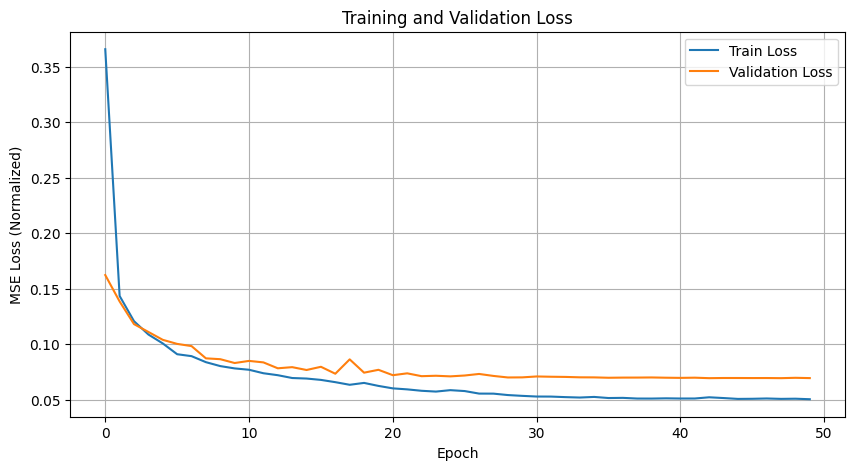

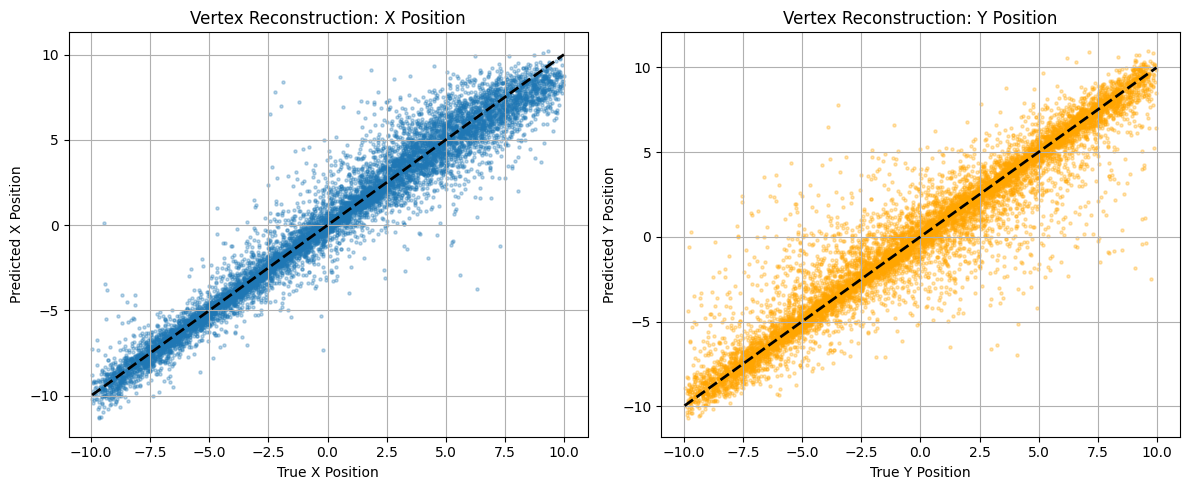

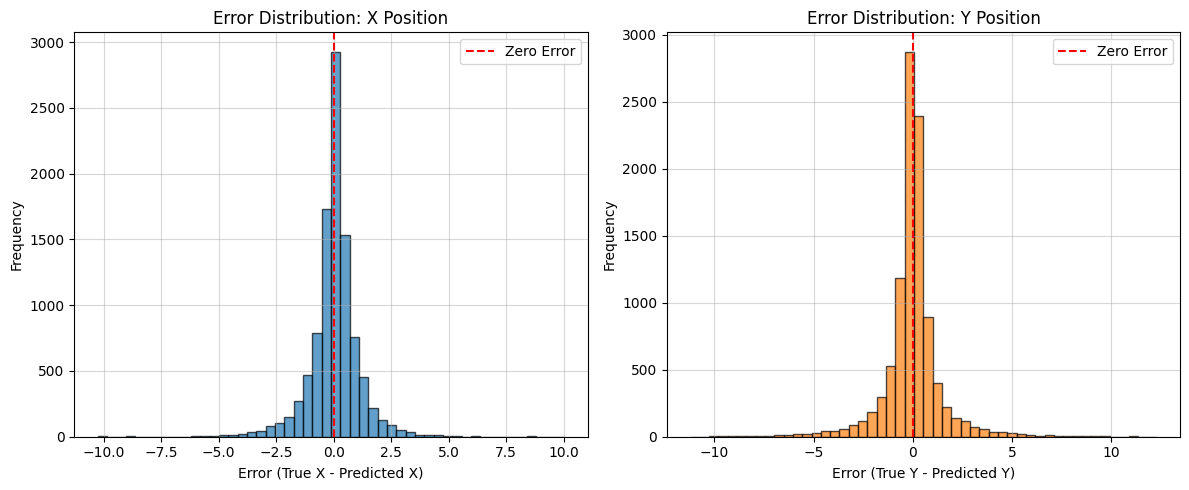

Mean Absolute Error (X): 0.7057
Mean Absolute Error (Y): 0.8675
---
Relative Average Error (X): 0.167165 (16.72%)
Relative Average Error (Y): 0.203116 (20.31%)


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Normalized)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

model.eval()
all_preds = []
all_truths = []

with torch.no_grad():
    for batch_data, batch_labels in validation_loader:
        
        data_vec = batch_data[0].to(device)
        lengths = batch_data[1]
        
        predictions = model([data_vec, lengths])
        
        all_preds.append(predictions.cpu().numpy())
        all_truths.append(batch_labels.cpu().numpy())

all_preds = np.vstack(all_preds)
all_truths = np.vstack(all_truths)

preds_x_real = (all_preds[:, 0] * norm_stds['xpos']) + norm_means['xpos']
preds_y_real = (all_preds[:, 1] * norm_stds['ypos']) + norm_means['ypos']
truths_x_real = (all_truths[:, 0] * norm_stds['xpos']) + norm_means['xpos']
truths_y_real = (all_truths[:, 1] * norm_stds['ypos']) + norm_means['ypos']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(truths_x_real, preds_x_real, alpha=0.3, s=5)
plt.plot([min(truths_x_real), max(truths_x_real)], [min(truths_x_real), max(truths_x_real)], 'k--', lw=2)
plt.xlabel('True X Position')
plt.ylabel('Predicted X Position')
plt.title('Vertex Reconstruction: X Position')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(truths_y_real, preds_y_real, alpha=0.3, s=5, color='orange')
plt.plot([min(truths_y_real), max(truths_y_real)], [min(truths_y_real), max(truths_y_real)], 'k--', lw=2)
plt.xlabel('True Y Position')
plt.ylabel('Predicted Y Position')
plt.title('Vertex Reconstruction: Y Position')
plt.grid(True)

plt.tight_layout()
plt.savefig('vertex_reconstruction.png')
plt.show()

residuals_x = truths_x_real - preds_x_real
residuals_y = truths_y_real - preds_y_real

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals_x, bins=50, alpha=0.7, color='tab:blue', edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Zero Error')
plt.xlabel('Error (True X - Predicted X)')
plt.ylabel('Frequency')
plt.title('Error Distribution: X Position')
plt.legend()
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(residuals_y, bins=50, alpha=0.7, color='tab:orange', edgecolor='black')
plt.axvline(x=0, color='r', linestyle='--', linewidth=1.5, label='Zero Error')
plt.xlabel('Error (True Y - Predicted Y)')
plt.ylabel('Frequency')
plt.title('Error Distribution: Y Position')
plt.legend()
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('residual_histograms.png')
plt.show()

mae_x = np.mean(np.abs(residuals_x))
mae_y = np.mean(np.abs(residuals_y))

mean_abs_true_x = np.mean(np.abs(truths_x_real))
mean_abs_true_y = np.mean(np.abs(truths_y_real))

rel_error_x = mae_x / mean_abs_true_x
rel_error_y = mae_y / mean_abs_true_y

print(f"Mean Absolute Error (X): {mae_x:.4f}")
print(f"Mean Absolute Error (Y): {mae_y:.4f}")
print("---")
print(f"Relative Average Error (X): {rel_error_x:.6f} ({rel_error_x * 100:.2f}%)")
print(f"Relative Average Error (Y): {rel_error_y:.6f} ({rel_error_y * 100:.2f}%)")